# 7. Two quantum algorithms

Everything is now in place: superposition (notebook 5), tensor products and
multi-qubit gates (notebook 6), unitary evolution throughout. This notebook puts
them to work on two problems where a quantum computer provably beats a classical
one.

Start with the trap. A Hadamard on each of $n$ qubits makes

$$|s\rangle = \frac{1}{\sqrt{2^n}}\sum_{x=0}^{2^n-1}|x\rangle,$$

all $2^n$ inputs at once, and a function can be evaluated on all of them in a
single pass. It sounds like the whole game is won. It is not: **measuring gives
one random $x$**, with probability $1/2^n$ each, which is exactly what guessing
would have given.

A quantum algorithm has to do a second thing. It must arrange the *phases* so
that the wrong answers cancel and the right ones add. Superposition is the cheap
part; interference is the algorithm.

In [1]:
(define (eye n) (m:generate n n (lambda (i j) (if (= i j) 1 0))))
(define (dagger M) (m:transpose ((m:elementwise conjugate) M)))
(define (density state) (* state (dagger state)))

(define (kron A B)
  (let ((rb (m:num-rows B)) (cb (m:num-cols B)))
    (m:generate (* (m:num-rows A) rb) (* (m:num-cols A) cb)
      (lambda (i j) (* (ref A (quotient i rb) (quotient j cb))
                       (ref B (remainder i rb) (remainder j cb)))))))

;; |i> in a D-dimensional space, and the uniform superposition over all of it.
(define (basis D i) (m:generate D 1 (lambda (r c) (if (= r i) 1 0))))
(define (uniform D) (m:generate D 1 (lambda (r c) (/ 1 (sqrt D)))))

(define gate-H (* (/ 1 (sqrt 2)) (matrix-by-rows (list 1 1) (list 1 -1))))

(define (amplitudes state)
  (map (lambda (i) (real-part (ref state i 0))) (iota (m:num-rows state))))

(define (prob-of state i) (square (magnitude (ref state i 0))))

eye 
dagger 
density 
kron 
basis 
uniform 
gate-H 
amplitudes 
prob-of 

## 7.1 Oracles, and phase kickback

Both algorithms are given a function $f$ as a black box and counted on how many
times they look inside. Classically you call $f$; quantumly you need a *unitary*,
because every quantum operation is reversible. The standard construction adds an
output register:

$$U_f\,|x\rangle|y\rangle = |x\rangle\,|y \oplus f(x)\rangle .$$

That is reversible whatever $f$ does -- applying it twice gets you back.

In [2]:
;; U_f for a one-bit f, on two qubits. Basis index = 2x + y.
(define (Uf f)
  (m:generate 4 4 (lambda (r c)
    (let ((x (quotient c 2)) (y (remainder c 2)))
      (if (= r (+ (* 2 x) (bitwise-xor y (f x)))) 1 0)))))

Uf 

Now the trick the whole subject rests on. Put the *output* register in
$|-\rangle = (|0\rangle - |1\rangle)/\sqrt2$ instead of $|0\rangle$. Flipping that
state does nothing but change its sign, so

$$U_f\,|x\rangle|-\rangle = (-1)^{f(x)}\,|x\rangle|-\rangle .$$

The output register is unchanged, and the answer has moved into a **phase on the
input register**. This is called *phase kickback*, and it is how a question about
values becomes a question about interference.

In [3]:
(define minus (* (/ 1 (sqrt 2)) (- (basis 2 0) (basis 2 1))))
(define (x-with-minus x) (kron (basis 2 x) minus))

(define f-balanced (lambda (x) x))          ; f(0)=0, f(1)=1

;; U_f |1>|-> should equal -|1>|->, so the difference is zero.
(print-expression
  (- (* (Uf f-balanced) (x-with-minus 1))
     (* -1 (x-with-minus 1))))

minus 
x-with-minus 
f-balanced 
(matrix-by-rows (list 0) (list 0) (list 0.) (list 0.))

;No return value.

Exactly zero: $f(1) = 1$ produced precisely a minus sign, and nothing else moved.

## 7.2 Deutsch's algorithm

The problem, from 1985 -- the first quantum algorithm ever found. You are given a
black box $f:\{0,1\}\to\{0,1\}$. There are four such functions: two **constant**
($f \equiv 0$, $f \equiv 1$) and two **balanced** ($f(x) = x$, $f(x) = 1-x$). Which
kind is it?

Classically you must evaluate $f(0)$ *and* $f(1)$: one value alone tells you
nothing. **Two queries, and two is provably necessary.** Deutsch's algorithm does
it in one.

The circuit is three steps. Prepare $|0\rangle|1\rangle$, Hadamard both, apply
$U_f$, Hadamard the first qubit back, measure it.

In [4]:
(define (deutsch f)
  (let* ((start (kron (basis 2 0) (basis 2 1)))            ; |0>|1>
         (super (* (kron gate-H gate-H) start))            ; |+>|->
         (kicked (* (Uf f) super))                         ; phases applied
         (out (* (kron gate-H (eye 2)) kicked)))           ; interfere
    ;; Probability the first qubit reads 1: basis states |10> and |11>.
    (+ (prob-of out 2) (prob-of out 3))))

(list 'const-0 (deutsch (lambda (x) 0))
      'const-1 (deutsch (lambda (x) 1))
      'balanced-x (deutsch (lambda (x) x))
      'balanced-not-x (deutsch (lambda (x) (- 1 x))))

deutsch 
#|
(const-0 0.
         const-1
         0.
         balanced-x
         .9999999999999996
         balanced-not-x
         .9999999999999996)
|#

**0 for both constant functions and 1 for both balanced ones** -- not 90%, but
certainty, from one query.

The mechanism is visible in the middle line. After the kickback the first qubit
is $\tfrac{1}{\sqrt2}\big((-1)^{f(0)}|0\rangle + (-1)^{f(1)}|1\rangle\big)$. If
$f(0) = f(1)$ the two signs match and the state is $\pm|+\rangle$; if they differ
it is $\pm|-\rangle$. The final Hadamard maps $|+\rangle \to |0\rangle$ and
$|-\rangle \to |1\rangle$, so the measurement reads off *whether the two values
agree* -- which is the question asked -- without ever revealing either value.

That is the shape of every quantum algorithm: compute a **global property** of $f$
that interference can expose, rather than the individual values, which it cannot.

## 7.3 Grover's algorithm

A more useful problem. There are $N$ items and exactly one of them is marked; a
black box tells you whether a given item is the marked one. Find it.

Classically there is nothing to do but try items until one works: $N/2$ queries
on average, $N$ in the worst case. Grover's algorithm (1996) needs about
$\tfrac{\pi}{4}\sqrt N$. That is a quadratic speedup, and it applies to any
brute-force search, which is a very large class of problems.

Two ingredients. The **oracle** flips the sign of the marked item and leaves the
rest alone -- phase kickback again, written directly:

$$O = I - 2|w\rangle\langle w| .$$

The **diffuser** reflects every amplitude about the mean:

$$D = 2|s\rangle\langle s| - I,$$

with $|s\rangle$ the uniform superposition.

In [5]:
(define (oracle D w) (- (eye D) (* 2 (density (basis D w)))))
(define (diffuser D)  (- (* 2 (density (uniform D))) (eye D)))

;; k rounds of (diffuser . oracle), starting from the uniform superposition.
(define (grover D w k)
  (let loop ((i 0) (state (uniform D)))
    (if (= i k) state (loop (+ i 1) (* (diffuser D) (oracle D w) state)))))

oracle 
diffuser 
grover 

Why it works: the oracle makes the marked amplitude negative, which drags the
*average* amplitude down slightly; reflecting about that average then throws the
marked amplitude far above it while nudging all the others down. Each round adds a
fixed amount to the marked amplitude, so the *probability* grows quadratically.

### Four items

With $N = 4$ one round is not an approximation -- it is exact.

In [6]:
(map (lambda (k) (list 'rounds k 'p-marked (prob-of (grover 4 2 k) 2)))
     (list 0 1 2 3))

#|
((rounds 0 p-marked 1/4) (rounds 1 p-marked 1)
                         (rounds 2 p-marked 1/4)
                         (rounds 3 p-marked 1/4))
|#

Exactly $1$ after one round, as an exact rational -- no floating point. One query
against the classical $2.25$ on average.

And note what happens at round 2: the probability falls back to $1/4$. **Grover
overshoots if you keep going.** Unlike a classical search, more work makes it
worse, so knowing when to stop is part of the algorithm.

### Eight items

In [7]:
(define (plot-data win xs ys)
  (let loop ((xs xs) (ys ys))
    (if (and (pair? (cdr xs)) (pair? (cdr ys)))
        (begin (plot-line win (car xs) (car ys) (cadr xs) (cadr ys))
               (loop (cdr xs) (cdr ys))))))

;; A bar chart as ONE polyline: up from the axis, back down, on to the next.
;; Drawing it this way keeps the whole series in a single colour. The offset
;; shifts a series sideways so two of them can sit next to each other.
(define (bar-points amps offset)
  (let loop ((i 0) (as amps))
    (if (null? as)
        '()
        (let ((x (+ (exact->inexact i) offset)))
          (append (list (list x 0.)
                        (list x (exact->inexact (car as)))
                        (list x 0.))
                  (loop (+ i 1) (cdr as)))))))

(define (plot-bars win amps offset)
  (let ((pts (bar-points amps offset)))
    (plot-data win (map car pts) (map cadr pts))))

plot-data 
bar-points 
plot-bars 

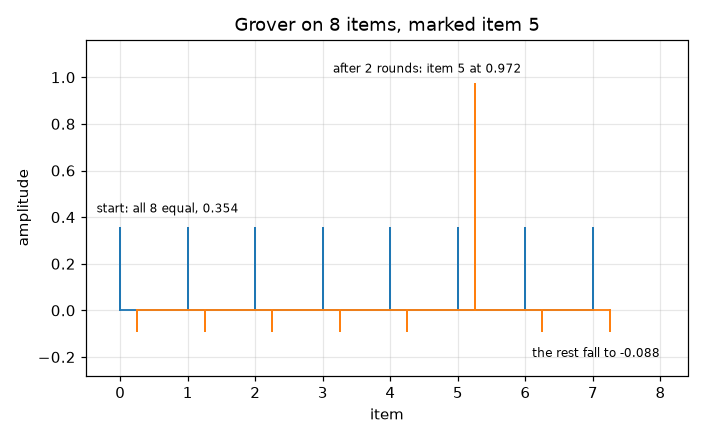

In [8]:
%%plot --title "Grover on 8 items, marked item 5" --xlabel "item" --ylabel "amplitude" --grid
(define win (frame -.5 8.4 -.28 1.16))
(plot-bars win (amplitudes (grover 8 5 0)) 0.)      ; before
(plot-bars win (amplitudes (grover 8 5 2)) .25)     ; after two rounds
(graphics-draw-text win -.35 .42 "start: all 8 equal, 0.354")
(graphics-draw-text win 3.15 1.02 "after 2 rounds: item 5 at 0.972")
(graphics-draw-text win 6.1 -.2 "the rest fall to -0.088")

Item 5 climbs from $0.354$ to $0.972$ over two rounds while the other seven sink
slightly negative -- and then, on the third round, falls back. Amplitude is
conserved; Grover moves it from the wrong answers to the right one.

### How many rounds?

The state never leaves the two-dimensional plane spanned by "the marked item" and
"everything else", and each round is a **rotation by a fixed angle** $2\theta$ in
that plane, where $\sin\theta = 1/\sqrt N$. After $k$ rounds the success
probability is $\sin^2\big((2k+1)\theta\big)$. That is a prediction we can check
against the simulation.

In [9]:
(define (grover-theory D k)
  (let ((theta (asin (/ 1. (sqrt D)))))
    (square (sin (* (+ (* 2 k) 1) theta)))))

(map (lambda (k) (list 'rounds k
                       'simulated (exact->inexact (prob-of (grover 8 5 k) 5))
                       'rotation-formula (grover-theory 8 k)))
     (list 0 1 2 3 4 5 6))

grover-theory 
#|
((rounds 0 simulated .12499999999999997 rotation-formula .12499999999999997)
 (rounds 1 simulated .7812499999999997 rotation-formula .7812499999999999)
 (rounds 2 simulated .9453124999999996 rotation-formula .9453125000000001)
 (rounds 3 simulated .33007812499999983 rotation-formula .330078125)
 (rounds 4
         simulated
         1.2207031249999955e-2
         rotation-formula
         1.2207031249999894e-2)
 (rounds 5 simulated .5479736328124988 rotation-formula .5479736328125)
 (rounds 6 simulated .9997863769531229 rotation-formula .9997863769531249))
|#

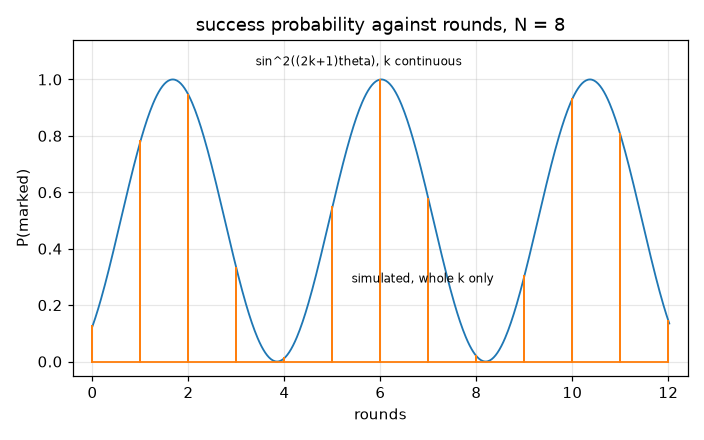

In [10]:
%%plot --title "success probability against rounds, N = 8" --xlabel "rounds" --ylabel "P(marked)" --grid
(define win (frame -.4 12.4 -.05 1.14))
(plot-function win (lambda (k) (grover-theory 8 k)) 0. 12. .02)
;; The simulation only exists at whole k, so draw it as stems, not a curve.
(plot-bars win (map (lambda (k) (prob-of (grover 8 5 k) 5)) (iota 13)) 0.)
(graphics-draw-text win 3.4 1.05 "sin^2((2k+1)theta), k continuous")
(graphics-draw-text win 5.4 .28 "simulated, whole k only")

The simulated points sit on the continuous rotation curve exactly. The peak for
$N = 8$ is at $k = 2$ with $P = 0.945$, and $\tfrac{\pi}{4}\sqrt8 = 2.22$ rounds
is what the formula asks for -- rounded to the nearest whole rotation, 2.

Then it oscillates. Run too long and you rotate past the marked state and out the
other side.

## 7.4 The speedup

$\tfrac{\pi}{4}\sqrt N$ against $N/2$. For a phone book of a million entries,
about 785 queries instead of 500,000.

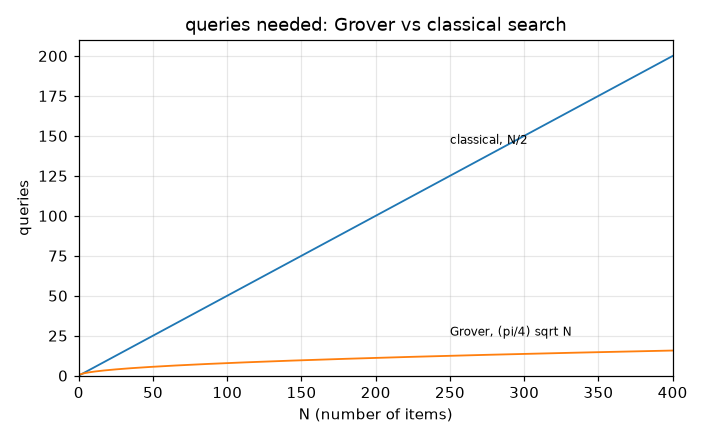

In [11]:
%%plot --title "queries needed: Grover vs classical search" --xlabel "N (number of items)" --ylabel "queries" --grid
(define win (frame 0. 400. 0. 210.))
(plot-function win (lambda (n) (* .5 n)) 1. 400. 1.)
(plot-function win (lambda (n) (* (/ pi 4.) (sqrt n))) 1. 400. 1.)
(graphics-draw-text win 250. 145. "classical, N/2")
(graphics-draw-text win 250. 25. "Grover, (pi/4) sqrt N")

Worth being precise about what this is and is not. **It is quadratic, not
exponential.** Doubling your qubits does not make search exponentially faster; it
makes it $\sqrt2$ times better per doubling of $N$. Grover is also provably
*optimal* -- no quantum algorithm can search an unstructured space faster -- so
this is the ceiling for brute force, not a stepping stone.

The exponential speedups live elsewhere, in problems with structure a quantum
Fourier transform can expose: factoring (Shor), period finding, and simulating
quantum systems, which is the one this whole series has really been about. A
quantum computer is a natural host for the mathematics of notebooks 3 and 4.

## What to carry forward

- Superposition is free and useless on its own; **interference** is the algorithm.
- Phase kickback turns a question about values into a question about phases.
- Deutsch: one query where classical needs two, by asking a *global* question.
- Grover: $\tfrac{\pi}{4}\sqrt N$ instead of $N/2$, exact for $N = 4$, and it
  overshoots if you run it too long.
- The speedup here is quadratic. Exponential speedups need structure.

---

That closes the series. From a Lagrangian written as a Scheme procedure in
notebook 1, through a quantized oscillator, to algorithms -- and the same
harmonic oscillator Hamiltonian ran through all of it.